# Univariate
using same column to fill missing values (ex: mean. median).

# Multivariate:
Using multiple column to fill missing values. 

Univariate (numerical data):MEAN/MEDIAN, ARBITARY, ENDOFDIST, RANDOM

MEAN/MEDIAN: 
1. ADV: Simple.. 
2. DISADVANTAGE: Change distribution, add outliers, covariance/ corilation change.



In [ ]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt

In [6]:
from sklearn.model_selection import  train_test_split
from sklearn.impute import SimpleImputer
from sklearn.compose import ColumnTransformer

In [7]:
df = pd.read_csv(r'c:\Users\rajku\Downloads\titanic_toy.csv')

In [8]:
df.head()

,Age,Fare,Family,Survived
0,22.0,7.2500,1,0
1,38.0,71.2833,1,1
2,26.0,7.9250,0,1
3,35.0,53.1000,1,1
4,35.0,8.0500,0,0


In [9]:
df.isnull().mean()


Age         0.198653
Fare        0.050505
Family      0.000000
Survived    0.000000
dtype: float64

In [10]:
df.shape

(891, 4)

In [11]:
x_train, x_test, y_train, y_test = train_test_split(df.drop(columns='Survived'), df['Survived'], test_size=.2)

In [12]:
x_train.shape

(712, 3)

In [13]:
x_train.isnull().mean()

Age       0.210674
Fare      0.046348
Family    0.000000
dtype: float64

In [14]:
# Missing values by pandas
mean_age = df['Age'].mean()
median_age = df['Age'].median()
mean_fare = df['Fare'].mean()
median_fare = df['Fare'].median()

In [15]:
x_train['Age_mean'] = x_train['Age'].fillna(mean_age)
x_train['Age_median'] = x_train['Age'].fillna(median_age)
x_train['Fare_mean'] = x_train['Fare'].fillna(mean_fare)
x_train['Fare_median'] = x_train['Fare'].fillna(median_fare)   


In [16]:
x_train.sample(8)

,Age,Fare,Family,Age_mean,Age_median,Fare_mean,Fare_median
527,NaN,221.7792,0,29.699118,28.0,221.779200,221.7792
44,19.0,7.8792,0,19.000000,19.0,7.879200,7.8792
311,18.0,262.3750,4,18.000000,18.0,262.375000,262.3750
860,41.0,NaN,2,41.000000,41.0,32.279338,14.4542
802,11.0,120.0000,3,11.000000,11.0,120.000000,120.0000
587,60.0,79.2000,2,60.000000,60.0,79.200000,79.2000
588,22.0,8.0500,0,22.000000,22.0,8.050000,8.0500
289,22.0,7.7500,0,22.000000,22.0,7.750000,7.7500


In [17]:
# Variance Daviation slightly shrink after mean/median
print("Original Age variable varience", x_train['Age'].var())
print("Age varience after median imputation", x_train['Age_median'].var())
print('Age variance after mean imputation ', x_train['Age_mean'].var())

print("Original Fare variable varience", x_train['Fare'].var())
print("Fare varience after median imputation", x_train['Fare_mean'].var())
print('Fare variance after mean imputation ', x_train['Fare_median'].var())

Original Age variable varience 201.7395966978768
Age varience after median imputation 159.50236269358652
Age variance after mean imputation  159.19394506859825
Original Fare variable varience 2530.8834441051663
Fare varience after median imputation 2413.471107434286
Fare variance after mean imputation  2429.2910380177555


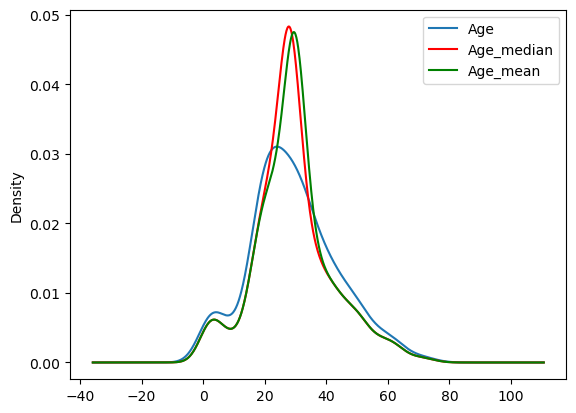

In [18]:

fig = plt.figure()
ax = fig.add_subplot(111)

# original variable distribution
x_train['Age'].plot(kind='kde', ax=ax)

# variable imputed with the median
x_train['Age_median'].plot(kind='kde', ax=ax, color='red')

# variable imputed with the mean
x_train['Age_mean'].plot(kind='kde', ax=ax, color='green')

# add legends
lines, labels = ax.get_legend_handles_labels()
ax.legend(lines, labels, loc='best')

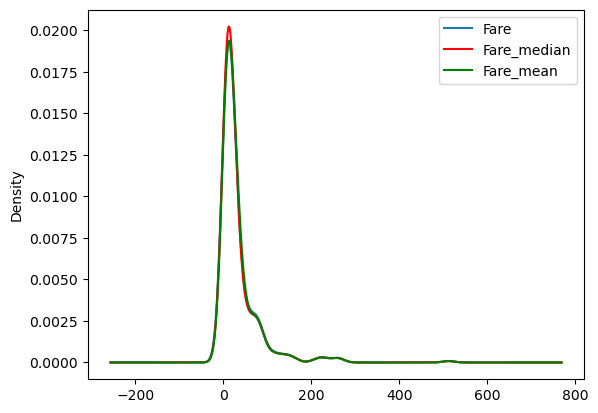

In [19]:

fig = plt.figure()
ax = fig.add_subplot(111)

# original variable distribution
x_train['Fare'].plot(kind='kde', ax=ax)

# variable imputed with the median
x_train['Fare_median'].plot(kind='kde', ax=ax, color='red')

# variable imputed with the mean
x_train['Fare_mean'].plot(kind='kde', ax=ax, color='green')

# add legends
lines, labels = ax.get_legend_handles_labels()
ax.legend(lines, labels, loc='best')

In [20]:
x_train.cov()

,Age,Fare,Family,Age_mean,Age_median,Fare_mean,Fare_median
Age,201.739597,95.563787,-5.691658,201.739597,201.739597,90.731147,90.430822
Fare,95.563787,2530.883444,18.164988,74.460043,77.972015,2530.883444,2530.883444
Family,-5.691658,18.164988,2.723082,-4.495842,-4.468192,17.322302,17.328957
Age_mean,201.739597,74.460043,-4.495842,159.193945,159.107776,70.990227,70.768167
Age_median,201.739597,77.972015,-4.468192,159.107776,159.502363,74.334003,74.028782
Fare_mean,90.731147,2530.883444,17.322302,70.990227,74.334003,2413.471107,2414.349217
Fare_median,90.430822,2530.883444,17.328957,70.768167,74.028782,2414.349217,2429.291038


In [21]:
x_train.corr()

,Age,Fare,Family,Age_mean,Age_median,Fare_mean,Fare_median
Age,1.000000,0.125271,-0.272538,1.000000,1.000000,0.122423,0.121541
Fare,0.125271,1.000000,0.216070,0.117121,0.122530,1.000000,1.000000
Family,-0.272538,0.216070,1.000000,-0.215932,-0.214397,0.213675,0.213060
Age_mean,1.000000,0.117121,-0.215932,1.000000,0.998492,0.114529,0.113798
Age_median,1.000000,0.122530,-0.214397,0.998492,1.000000,0.119807,0.118926
Fare_mean,0.122423,1.000000,0.213675,0.114529,0.119807,1.000000,0.997101
Fare_median,0.121541,1.000000,0.213060,0.113798,0.118926,0.997101,1.000000


# Filling the Missing values by Sklearn
1. SimpleInputer()

In [ ]:
# SimpleImputer() function :
# missing_values: int, float, str, np.ana or none, (default= np.nan)
# strategy: string, default='mean'
# fill_value: string or numerical value, default=none
# add_indecator

In [34]:
x_train, x_test, y_train, y_test = train_test_split(df.drop(columns='Survived'), df['Survived'], test_size=.2)

In [35]:
imputer1 = SimpleImputer(strategy='median')
imputer2 = SimpleImputer(strategy='mean')

In [36]:
trf = ColumnTransformer([
    ('imputer1', imputer1,['Age']),
    ('imputer2', imputer2, ['Fare'])
], remainder='passthrough')

In [37]:
trf.fit(x_train)

c:\Users\rajku\anaconda3\Lib\site-packages\sklearn\compose\_column_transformer.py:1667: FutureWarning: 
The format of the columns of the 'remainder' transformer in ColumnTransformer.transformers_ will change in version 1.7 to match the format of the other transformers.
At the moment the remainder columns are stored as indices (of type int). With the same ColumnTransformer configuration, in the future they will be stored as column names (of type str).
To use the new behavior now and suppress this warning, use ColumnTransformer(force_int_remainder_cols=False).

  warnings.warn(


ColumnTransformer(remainder='passthrough',
                  transformers=[('imputer1', SimpleImputer(strategy='median'),
                                 ['Age']),
                                ('imputer2', SimpleImputer(), ['Fare'])])

In [38]:
trf.named_transformers_['imputer1'].statistics_         #median value of age

array([28.])

In [39]:
trf.named_transformers_['imputer2'].statistics_

array([33.41085385])

In [40]:
x_train = trf.transform(x_train)
x_test = trf.transform(x_test)

In [41]:
x_train

array([[ 28.    ,   7.7958,   0.    ],
       [ 28.    ,   7.8958,   0.    ],
       [ 30.5   ,   8.05  ,   0.    ],
       ...,
       [ 58.    , 153.4625,   1.    ],
       [ 16.    ,   9.5   ,   0.    ],
       [ 28.    ,  15.5   ,   1.    ]])

2. Arbitrary Value imputation

In [49]:
# Mostly used in catagorical data (Na --> Missing)
# in numerical replace by (-1 / 0 / 99.999)
# Easy to apply
# Graph distort/ varianch change / covar also changes / outliers formed

In [50]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
from sklearn.model_selection import  train_test_split
from sklearn.impute import SimpleImputer
from sklearn.compose import ColumnTransformer

In [51]:
df = pd.read_csv(r'c:\Users\rajku\Downloads\titanic_toy.csv')

In [52]:
x_train, x_test, y_train, y_test = train_test_split(df.drop(columns='Survived'), df['Survived'], test_size=.2)

In [54]:
x_train.head()

,Age,Fare,Family
161,40.0,15.7500,0
496,54.0,78.2667,1
741,36.0,78.8500,1
374,3.0,21.0750,4
189,36.0,7.8958,0


In [56]:
x_train['Age_mean'] = x_train['Age'].fillna(88)
x_train['Age_median'] = x_train['Age'].fillna(-1)
x_train['Fare_mean'] = x_train['Fare'].fillna(99)
x_train['Fare_median'] = x_train['Fare'].fillna(-1)

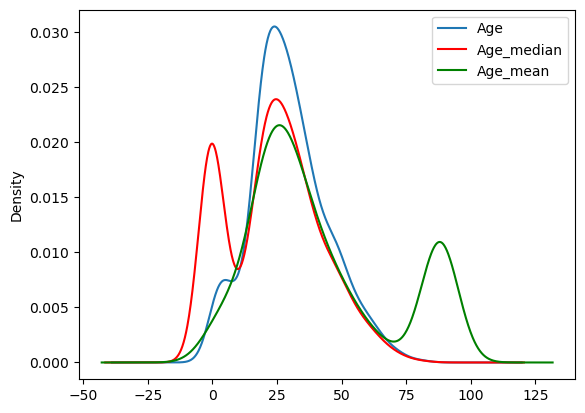

In [57]:
x_train
fig = plt.figure()
ax = fig.add_subplot(111)

# original variable distribution
x_train['Age'].plot(kind='kde', ax=ax)

# variable imputed with the median
x_train['Age_median'].plot(kind='kde', ax=ax, color='red')

# variable imputed with the mean
x_train['Age_mean'].plot(kind='kde', ax=ax, color='green')

# add legends
lines, labels = ax.get_legend_handles_labels()
ax.legend(lines, labels, loc='best')

End of Distribution Imputation 
1. Normally : (meand + 3*std) or (meand - 3*std)    # outlier
2. Skewed data: Q1 - 1.5 IQR  or Q3 + 1.5 IQR    # Q3 - 75%tile,Q1 - 25%tile